In [107]:
#THE UPDATED TED MANSELL PAPER VERSION
#This is specifically formatted for NSSL-2 microphysics in COMMAS. Modified last: 10/14/2024 KNB
#;@knb_calc_distro

from pandas.core.common import flatten
import numpy as np
import pickle
import matplotlib
import xarray as xr
import matplotlib.pyplot as plt
import math
import datetime
import time
import pyart
from scipy.io import readsav

def knb_calc_droplet_distro_COMMAS(q, qn, dry_density):

    sphere_c = (4./3.)*math.pi
    rho_water = 1000. # ;kg/m^3
    out_total = np.zeros(np.shape(q))
    size_arr = np.zeros(np.shape(q))
    ind = np.arange(41)*1e-6 
    mass = (ind**3.)*(4./3.)*math.pi*rho_water 
    #;mean mass
    Ndens = qn
    L = q*dry_density
    xbar =  L/Ndens
    
    for k ,qvalk in enumerate(q[0,:,0,0]): 
        print(k)
        for kk,qvalkk in enumerate(q[0,0,:,0]):
            # print(kk)
            for kkk,qvalkk in enumerate(q[0,0,0,:]):
                # print(kkk)
                out = np.zeros(len(ind))  
                for i in np.arange(len(ind)-2): 
                    x = (mass[i+1] - mass[i])/2. + mass[i]
                    out[i] = (((Ndens[0,k,kk,kkk])/xbar[0,k,kk,kkk])*math.exp(-(x/xbar[0,k,kk,kkk])))*(mass[i+1] - mass[i]) #output units are count per m^3
                size_arr[0,k,kk,kkk] = ((np.nansum((ind*out))/np.nansum(out)))
                out_total[0,k,kk,kkk] = np.nansum(out)

    return size_arr, out_total,ind,out

def knb_calc_raindrop_distro_COMMAS(q, qn, dry_density):
    sphere_c = (4./3.)*math.pi
    rho_water = 1000. # ;kg/m^3
    out_total = np.zeros(np.shape(q))
    size_arr = np.zeros(np.shape(q))
    ind = (np.arange(293)*5. + 40.)*1e-6 
    mass = (ind**3.)*sphere_c*rho_water
    #;mean mass
    Ndens = qn
    L = q*dry_density
    xbar =  L/Ndens
    
    for k ,qvalk in enumerate(q[0,:,0,0]): 
        print(k)
        for kk,qvalkk in enumerate(q[0,0,:,0]):
            # print(kk)
            for kkk,qvalkk in enumerate(q[0,0,0,:]):
                # print(kkk)
                out = np.zeros(len(ind)) 
                for i in np.arange(len(ind)-2): 
                    x = (mass[i+1] - mass[i])/2. + mass[i]
                    out[i] = ((Ndens[0,k,kk,kkk]/x)*((x/xbar[0,k,kk,kkk])**(-0.8))*0.15788*math.exp(-0.2*(x/xbar[0,k,kk,kkk])))*(mass[i+1] - mass[i])
                if np.nansum(out) == 0:
                    size_arr[0,k,kk,kkk] = 0.0
                else:
                    size_arr[0,k,kk,kkk] = ((np.nansum((ind*out))/np.nansum(out)))
                out_total[0,k,kk,kkk] = np.nansum(out)

    return size_arr, out_total,ind,out

def knb_calc_ice_distro_COMMAS(q, qn, dry_density):

    sphere_c = (4./3.)*math.pi
    rho_ice = 900.# ;kg/m^3
    out_total = np.zeros(np.shape(q))
    size_arr = np.zeros(np.shape(q))
    ind = np.arange(550)*5.*1E-6
    mass = (ind**3.)*sphere_c*rho_ice
    #;mean mass
    Ndens = qn
    L = q*dry_density
    xbar =  L/Ndens
    
    for k ,qvalk in enumerate(q[0,:,0,0]): 
        print(k)
        for kk,qvalkk in enumerate(q[0,0,:,0]):
            # print(kk)
            for kkk,qvalkk in enumerate(q[0,0,0,:]):
                # print(kkk)
                out = np.zeros(len(ind)) 
                for i in np.arange(len(ind)-2): 
                    x = (mass[i+1] - mass[i])/2. + mass[i]
                    out[i] = ((Ndens[0,k,kk,kkk]/xbar[0,k,kk,kkk])*math.exp(-(x/xbar[0,k,kk,kkk])))*(mass[i+1] - mass[i]) #output units are count per m^3
                size_arr[0,k,kk,kkk] = ((np.nansum((ind*out))/np.nansum(out)))
                out_total[0,k,kk,kkk] = np.nansum(out)

    return size_arr, out_total,ind,out 

def knb_calc_snow_distro_COMMAS(q, qn, dry_density):
    sphere_c = (4./3.)*math.pi
    rho_snow = 100. # ;kg/m^3
    out_total = np.zeros(np.shape(q))
    size_arr = np.zeros(np.shape(q))
    ind = np.arange(550)*5.*1e-6
    mass = (ind**3.)*sphere_c*rho_snow
    #;mean mass
    Ndens = qn
    L = q*dry_density
    xbar =  L/Ndens
    
    for k ,qvalk in enumerate(q[0,:,0,0]): 
        print(k)
        for kk,qvalkk in enumerate(q[0,0,:,0]):
            # print(kk)
            for kkk,qvalkk in enumerate(q[0,0,0,:]):
                # print(kkk)
                out = np.zeros(len(ind)) 
                for i in np.arange(len(ind)-2): 
                    x = (mass[i+1] - mass[i])/2. + mass[i]
                    out[i] = ((Ndens[0,k,kk,kkk]/x)*((x/xbar[0,k,kk,kkk])**(-0.8))*0.15788*math.exp(-0.2*(x/xbar[0,k,kk,kkk])))*(mass[i+1] - mass[i])
                size_arr[0,k,kk,kkk] = ((np.nansum((ind*out))/np.nansum(out)))
                out_total[0,k,kk,kkk] = np.nansum(out)

    return size_arr, out_total,ind,out


def knb_calc_graupel_distro_COMMAS(q, qn,volume, dry_density):
    #Graupel and hail have predicted particle density, which is computed from rho_air*q/V, 
    #where V is the total particle volume (m^3/m^3) (QHW/VHW for graupel, QHL/VHL for hail). 
    rho_graup = dry_density*(q/volume) # ;kg/m^3, the range in Mansell et all is 300-900kg/m^3
    sphere_c = (4./3.)*math.pi
    out_total = np.zeros(np.shape(q))
    size_arr = np.zeros(np.shape(q))
    #100microns to 2595microns in increments of 5microns
    ind = (np.arange(501)*5. + 100.)*1e-6 
    # mass = (ind**3.)*sphere_c*rho_graup
    #;mean mass
    Ndens = qn
    L = q
    xbar =  L/Ndens
    
    for k ,qvalk in enumerate(q[0,:,0,0]): 
        print(k)
        for kk,qvalkk in enumerate(q[0,0,:,0]):
            # print(kk)
            for kkk,qvalkk in enumerate(q[0,0,0,:]):
                # print(kkk)
                mass = (ind**3.)*sphere_c*rho_graup[0,k,kk,kkk]
                out = np.zeros(len(ind)) 
                for i in np.arange(len(ind)-2): 
                    x = (mass[i+1] - mass[i])/2. + mass[i]
                    out[i] = (Ndens[0,k,kk,kkk]/xbar[0,k,kk,kkk])*((x/xbar[0,k,kk,kkk])**(-2./3.))*0.60571*math.exp(-((6*(x/xbar[0,k,kk,kkk]))**(1./3.)))*(mass[i+1] - mass[i])
                size_arr[0,k,kk,kkk] = ((np.nansum((ind*out))/np.nansum(out)))
                out_total[0,k,kk,kkk] = np.nansum(out)
    return size_arr, out_total,ind,out 

def knb_calc_hail_distro_COMMAS(q, qn, volume,dry_density):
    #Graupel and hail have predicted particle density, which is computed from rho_air*q/V, 
    #where V is the total particle volume (m^3/m^3) (QHW/VHW for graupel, QHL/VHL for hail). 
    rho_hail = dry_density*(q/volume) # ;kg/m^3, the range in Mansell et all is 300-900kg/m^3
    sphere_c = (4./3.)*math.pi
    # rho_hail = 800. 
    out_total = np.zeros(np.shape(q))
    size_arr = np.zeros(np.shape(q))
    #100microns to 2595microns in increments of 5microns
    ind = (np.arange(481)*50.)*1E-6 #;1mm to 2.5cm in meters, increments of 50 microns
    # mass = (ind**3.)*sphere_c*rho_hail
    #;mean mass
    Ndens = qn
    L = q*dry_density
    xbar =  L/Ndens
    
    for k ,qvalk in enumerate(q[0,:,0,0]): 
        print(k)
        for kk,qvalkk in enumerate(q[0,0,:,0]):
            # print(kk)
            for kkk,qvalkk in enumerate(q[0,0,0,:]):
                # print(kkk)
                mass = (ind**3.)*sphere_c*rho_hail[0,k,kk,kkk]
                out = np.zeros(len(ind)) 
                for i in np.arange(len(ind)-2): 
                    x = (mass[i+1] - mass[i])/2. + mass[i]
                    out[i] = (Ndens[0,k,kk,kkk]/xbar[0,k,kk,kkk])*((x/xbar[0,k,kk,kkk])**(-2./3.))*0.60571*math.exp(-((6*(x/xbar[0,k,kk,kkk]))**(1./3.)))*(mass[i+1] - mass[i])
                size_arr[0,k,kk,kkk] = ((np.nansum((ind*out))/np.nansum(out)))
                out_total[0,k,kk,kkk] = np.nansum(out)
                
    return size_arr, out_total,ind,out

In [37]:
data = xr.open_dataset("/Users/kelcy/DATA/mbrothers_sim/1000m/KTAL071015B_30s.002400.nc")

In [38]:
data

<xarray.Dataset>
Dimensions:     (TIME: 1, XC: 40, XE: 41, YC: 40, YE: 41, ZC: 160, ZE: 161)
Coordinates:
  * TIME        (TIME) timedelta64[ns] 00:40:00
  * XC          (XC) float32 500.0 1.5e+03 2.5e+03 ... 3.85e+04 3.95e+04
  * XE          (XE) float32 0.0 1e+03 2e+03 3e+03 ... 3.8e+04 3.9e+04 4e+04
  * YC          (YC) float32 500.0 1.5e+03 2.5e+03 ... 3.85e+04 3.95e+04
  * YE          (YE) float32 0.0 1e+03 2e+03 3e+03 ... 3.8e+04 3.9e+04 4e+04
  * ZC          (ZC) float32 62.5 187.5 312.5 ... 1.969e+04 1.981e+04 1.994e+04
  * ZE          (ZE) float32 0.0 125.0 250.0 375.0 ... 1.975e+04 1.988e+04 2e+04
Data variables: (12/206)
    NX          int32 ...
    NY          int32 ...
    NZ          int32 ...
    NG          int32 ...
    NXEND       int32 ...
    NYEND       int32 ...
    ...          ...
    SCCI        (TIME, ZC, YC, XC) float32 ...
    SCSW        (TIME, ZC, YC, XC) float32 ...
    SCHW        (TIME, ZC, YC, XC) float32 ...
    SCHL        (TIME, ZC, YC, XC) float32 ...
    CPION       (TIME, ZC, YC, XC) float32 ...
    CNION       (TIME, ZC, YC, XC) float32 ...
Attributes: (12/19)
    NZ:                161
    NG:                3
    NXEND:             41
    NYEND:             41
    NZEND:             161
    PREFIX_NAME:       KTAL071015B_30s
    ...                ...
    YEAR:              2007
    MONTH:             1
    DAY:               20
    HOUR:              0
    MINUTE:            0
    SECOND:            0

In [39]:
z_unstag = data['ZC'].values

In [40]:
piinit0_pi = np.zeros(data['PI'].shape)
for i in np.arange(len(data['XC'])):
    for j in np.arange(len(data['YC'])):
        piinit0_pi[0,:,i,j] = data['PI'][0,:,i,j].values+data['PIINIT0'].values
        
expdenom = (287.04*data['TH'].values)
rho_air = 1.0e5*(piinit0_pi**2.509)/expdenom

In [57]:
#DROPLET #3d profile version

szdrop, cntdrop,ind,out = knb_calc_droplet_distro_COMMAS(data['QC'].values, data['CCW'].values, rho_air)

/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/4094165840.py:28: RuntimeWarning: invalid value encountered in divide
  xbar =  L/Ndens
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/4094165840.py:40: RuntimeWarning: invalid value encountered in scalar divide
  size_arr[0,k,kk,kkk] = ((np.nansum((ind*out))/np.nansum(out)))


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159


In [91]:
print([np.nanmean(szdrop)*1e6,np.nanmin(szdrop)*1e6,np.nanmax(szdrop)*1e6])
print([np.nanmean(cntdrop)/1e6,np.nanmin(cntdrop)/1e6,np.nanmax(cntdrop)/1e6])

[8.551894512219592, 3.066430557898126e-05, 28.74311134822271]
[0.8684692409968505, 0.0, 659.5044061536483]


In [88]:
#RAIN #3d profile version

szrain, cntrain ,ind,out= knb_calc_raindrop_distro_COMMAS(data['QR'].values,data['CRW'].values,rho_air)

/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/1797121931.py:55: RuntimeWarning: invalid value encountered in divide
  xbar =  L/Ndens


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159


In [92]:
print([np.nanmean(szrain)*1e6,np.nanmin(szrain)*1e6,np.nanmax(szrain)*1e6])
print([np.nanmean(cntrain)/1e6,np.nanmin(cntrain)/1e6,np.nanmax(cntrain)/1e6])

[2.886965168564218, 0.0, 65.9501955383693]
[0.0012198000921984202, 0.0, 0.6918244220508547]


In [94]:
#ICE #3d profile version

szice, cntice,ind,out = knb_calc_ice_distro_COMMAS(data['QI'].values,data['CCI'].values,rho_air)

/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/1797121931.py:86: RuntimeWarning: invalid value encountered in divide
  xbar =  L/Ndens
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/1797121931.py:98: RuntimeWarning: invalid value encountered in scalar divide
  size_arr[0,k,kk,kkk] = ((np.nansum((ind*out))/np.nansum(out)))


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159


In [95]:
print([np.nanmean(szice)*1e6,np.nanmin(szice)*1e6,np.nanmax(szice)*1e6])
print([np.nanmean(cntice)/1e6,np.nanmin(cntice)/1e6,np.nanmax(cntice)/1e6])

[30.569106901948143, 1.5576809232472646, 121.08332015735124]
[0.048293732031845456, 0.0, 26.221247500820752]


In [97]:
#GRAUPEL #3d profile version

szgraup, cntgraup,ind,out = knb_calc_graupel_distro_COMMAS(data['QH'].values,data['CHW'].values,data['VHW'].values, rho_air)

/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/1797121931.py:134: RuntimeWarning: invalid value encountered in divide
  rho_graup = dry_density*(q/volume) # ;kg/m^3, the range in Mansell et all is 300-900kg/m^3
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/1797121931.py:144: RuntimeWarning: invalid value encountered in divide
  xbar =  L/Ndens
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/1797121931.py:157: RuntimeWarning: invalid value encountered in scalar divide
  size_arr[0,k,kk,kkk] = ((np.nansum((ind*out))/np.nansum(out)))


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159


In [98]:
print([np.nanmean(szgraup)*1e6,np.nanmin(szgraup)*1e6,np.nanmax(szgraup)*1e6])
print([np.nanmean(cntgraup)/1e6,np.nanmin(cntgraup)/1e6,np.nanmax(cntgraup)/1e6])

[358.45093503009855, 194.39019376144233, 1064.8335055023208]
[3.7336937198731866e-05, 0.0, 0.005886439800940314]


In [103]:
#HAIL #3d profile version
szhail, cnthail,ind,out = knb_calc_hail_distro_COMMAS(data['QHL'].values,data['CHL'].values,data['VHL'].values, rho_air)

/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/3879936245.py:164: RuntimeWarning: invalid value encountered in divide
  rho_hail = dry_density*(q/volume) # ;kg/m^3, the range in Mansell et all is 300-900kg/m^3
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/3879936245.py:175: RuntimeWarning: invalid value encountered in divide
  xbar =  L/Ndens
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/3879936245.py:188: RuntimeWarning: invalid value encountered in scalar divide
  size_arr[0,k,kk,kkk] = ((np.nansum((ind*out))/np.nansum(out)))


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159


In [104]:
print([np.nanmean(szhail)*1e6,np.nanmin(szhail)*1e6,np.nanmax(szhail)*1e6])
print([np.nanmean(cnthail)/1e6,np.nanmin(cnthail)/1e6,np.nanmax(cnthail)/1e6])

[611.9259867224805, 193.26847423367425, 5546.784008955111]
[1.406287408317424e-07, 0.0, 0.00016958130627124722]


In [108]:
#SNOW 3D profile version
szsnow, cntsnow,ind,out = knb_calc_snow_distro_COMMAS(data['QS'].values,data['CSW'].values, rho_air)

/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/4102664037.py:113: RuntimeWarning: invalid value encountered in divide
  xbar =  L/Ndens
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/4102664037.py:125: RuntimeWarning: invalid value encountered in scalar divide
  size_arr[0,k,kk,kkk] = ((np.nansum((ind*out))/np.nansum(out)))


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159


In [109]:
print([np.nanmean(szsnow)*1e6,np.nanmin(szsnow)*1e6,np.nanmax(szsnow)*1e6])
print([np.nanmean(cntsnow)/1e6,np.nanmin(cntsnow)/1e6,np.nanmax(cntsnow)/1e6])

[1.291205640543972, 0.9127099661505005, 1.2999405179059735]
[2.538627616500898, 0.0, 799.8670751340395]


In [110]:
data['Q

(1, 160, 40, 40)

In [116]:
#ALL particles, not separated by liquid or frozen
particle_concentration = np.zeros(np.shape(data['QC']))
particle_size = np.zeros(np.shape(data['QC']))
for i in np.arange(159):
    for ii in np.arange(40):
        for iii in np.arange(40):
    
    #total concentration of liquid particle:
            particle_concentration[0,i,ii,iii] = (np.nansum((cntdrop[0,i,ii,iii], cntrain[0,i,ii,iii],cntgraup[0,i,ii,iii],cntice[0,i,ii,iii],cnthail[0,i,ii,iii],cntsnow[0,i,ii,iii])))
    
    #mean size of liquid particles
            top = np.nansum(((cntdrop[0,i,ii,iii]*szdrop[0,i,ii,iii]),(cntrain[0,i,ii,iii]*szrain[0,i,ii,iii]),(cntgraup[0,i,ii,iii]*szgraup[0,i,ii,iii]),(cntice[0,i,ii,iii]*szice[0,i,ii,iii]),(cnthail[0,i,ii,iii]*szhail[0,i,ii,iii]),(cntsnow[0,i,ii,iii]*szsnow[0,i,ii,iii])))
            bottom = np.nansum((cntdrop[0,i,ii,iii], cntrain[0,i,ii,iii],cntice[0,i,ii,iii],cntgraup[0,i,ii,iii],cnthail[0,i,ii,iii],cntsnow[0,i,ii,iii]))
            particle_size[0,i,ii,iii] = (top/bottom)

/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/2454356298.py:14: RuntimeWarning: invalid value encountered in scalar divide
  particle_size[0,i,ii,iii] = (top/bottom)


In [130]:
#Separated by particle type, at min 65, saved after each profile is made
droplet_concentration = np.zeros(np.shape(data['QC']))
droplet_size = np.zeros(np.shape(data['QC']))
rain_concentration = np.zeros(np.shape(data['QC']))
rain_size = np.zeros(np.shape(data['QC']))
graupel_concentration = np.zeros(np.shape(data['QC']))
graupel_size = np.zeros(np.shape(data['QC']))
ice_concentration = np.zeros(np.shape(data['QC']))
ice_size = np.zeros(np.shape(data['QC']))
hail_concentration = np.zeros(np.shape(data['QC']))
hail_size = np.zeros(np.shape(data['QC']))
snow_concentration = np.zeros(np.shape(data['QC']))
snow_size = np.zeros(np.shape(data['QC']))
for i in np.arange(159):
    for ii in np.arange(40):
        for iii in np.arange(40):
    
    #total concentration of Droplet particle:
            droplet_concentration[0,i,ii,iii] = (np.nansum((cntdrop[0,i,ii,iii],)))
    
    #mean size of Droplet particles
            top = np.nansum(((cntdrop[0,i,ii,iii]*szdrop[0,i,ii,iii])))
            bottom = np.nansum((cntdrop[0,i,ii,iii]))
            droplet_size[0,i,ii,iii] = (top/bottom)
            
            
    #total concentration of Rain particle:
            rain_concentration[0,i,ii,iii] = (np.nansum((cntrain[0,i,ii,iii])))
    
    #mean size of Rain particles
            top = np.nansum(((cntrain[0,i,ii,iii]*szrain[0,i,ii,iii])))
            bottom = np.nansum((cntrain[0,i,ii,iii]))
            rain_size[0,i,ii,iii] = (top/bottom)
            
    #total concentration of GRAUPEL particle:
            graupel_concentration[0,i,ii,iii] = (np.nansum((cntgraup[0,i,ii,iii])))
    
    #mean size of GRAUPEL particles
            top = np.nansum(((cntgraup[0,i,ii,iii]*szgraup[0,i,ii,iii])))
            bottom = np.nansum((cntgraup[0,i,ii,iii]))
            graupel_size[0,i,ii,iii] = (top/bottom)

    #total concentration of ICE particle:
            ice_concentration[0,i,ii,iii] = (np.nansum(cntice[0,i,ii,iii]))
    
    #mean size of ICE particles
            top = np.nansum(((cntice[0,i,ii,iii]*szice[0,i,ii,iii])))
            bottom = np.nansum((cntice[0,i,ii,iii]))
            ice_size[0,i,ii,iii] = (top/bottom)

    #total concentration of HAIL particle:
            hail_concentration[0,i,ii,iii] = (np.nansum((cnthail[0,i,ii,iii])))
    
    #mean size of HAIL particles
            top = np.nansum(((cnthail[0,i,ii,iii]*szhail[0,i,ii,iii])))
            bottom = np.nansum((cnthail[0,i,ii,iii]))
            hail_size[0,i,ii,iii] = (top/bottom)

    #total concentration of SNOW particle:
            snow_concentration[0,i,ii,iii] = (np.nansum((cntsnow[0,i,ii,iii])))
    
    #mean size of SNOW particles
            top = np.nansum(((cntsnow[0,i,ii,iii]*szsnow[0,i,ii,iii])))
            bottom = np.nansum((cntsnow[0,i,ii,iii]))
            snow_size[0,i,ii,iii] = (top/bottom)
            

x = x = np.arange(0,40,1)#[0,1,2,3,4,5,6,7,8,9]
y = x
print(len(y))
z = z_unstag
time = np.zeros(1)
ds = xr.Dataset(
    data_vars=dict(
        droplet_count = (["time","z","y", "x"], droplet_concentration),
        droplet_size = (["time","z","y", "x"], droplet_size),
        rain_count = (["time","z","y", "x"], rain_concentration),
        rain_size = (["time","z","y", "x"], rain_size),
        graupel_count = (["time","z","y", "x"], graupel_concentration),
        graupel_size = (["time","z","y", "x"], graupel_size),
        ice_count = (["time","z","y", "x"], ice_concentration),
        ice_size = (["time","z","y", "x"], ice_size),
        hail_count = (["time","z","y", "x"], hail_concentration),
        hail_size = (["time","z","y", "x"], hail_size),
        snow_count = (["time","z","y", "x"], snow_concentration),
        snow_size = (["time","z","y", "x"], snow_size),
        particle_size = (["time","z","y","x"],particle_size),
        particle_concentration = (["time","z","y","x"],particle_concentration),
    ),
    coords=dict(
        time = ("time",time),
        x=("x", x),
        y=("y", y),
        z=("z",z),
    ),
    attrs=dict(description="3D profile for COMMAS Simulation"))
# ds.to_netcdf('3D_distro_single_element_COMMAS.nc')

/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/256819853.py:24: RuntimeWarning: invalid value encountered in scalar divide
  droplet_size[0,i,ii,iii] = (top/bottom)
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/256819853.py:33: RuntimeWarning: invalid value encountered in scalar divide
  rain_size[0,i,ii,iii] = (top/bottom)
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/256819853.py:41: RuntimeWarning: invalid value encountered in scalar divide
  graupel_size[0,i,ii,iii] = (top/bottom)
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/256819853.py:49: RuntimeWarning: invalid value encountered in scalar divide
  ice_size[0,i,ii,iii] = (top/bottom)
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/256819853.py:57: RuntimeWarning: invalid value encountered in scalar divide
  hail_size[0,i,ii,iii] = (top/bottom)
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_58960/256819853.py:65: RuntimeWarnin

40


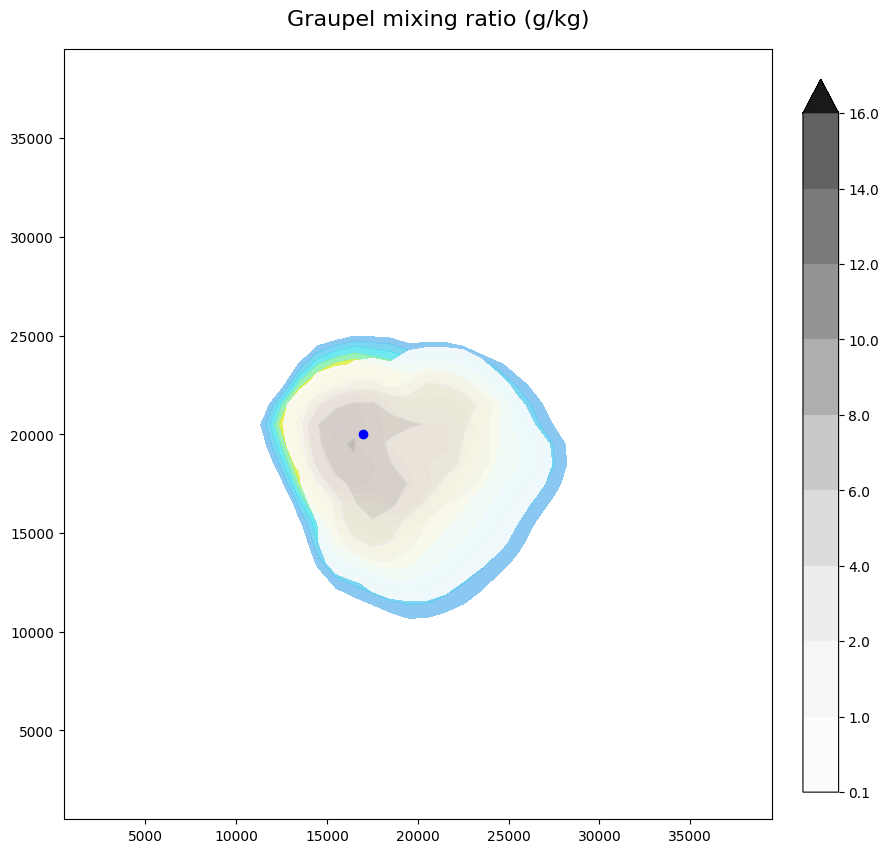

In [145]:
maxrefl = data['DBZ'].max(axis=1)
# maxrefl = data['DBZ'].max(axis=1)
cloud = data['QH']#data['QICE'] + data['QCLOUD']
max_Qvapor = cloud.max(axis=1)


ref_levels = [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75]
q_levels = [0.1,1,2,4,6,8,10,12,14,16]

fig, ax = plt.subplots(figsize=(10,10))


y_mesh,x_mesh = np.meshgrid(data['YC'],data['XC'])
    
refplt = ax.contourf(y_mesh,x_mesh, maxrefl[0,:,:], extend = 'max',levels = ref_levels,cmap='pyart_LangRainbow12',origin = 'lower', vmin=-24, vmax=72,alpha = 0.8)#,extent = [0,-10000,-20000,-10000])
qvapplt = ax.contourf(y_mesh,x_mesh, max_Qvapor[0,:,:]*1e3, extend = 'max',alpha = 0.9,levels = q_levels,cmap='Greys',origin = 'lower', vmin = 0, vmax = 20)#,extent = [0,-10000,-20000,-10000])

fig.colorbar(qvapplt,fraction=0.046, pad=0.04)

pt = ax.scatter(17000,20000,marker = 'o' ,color = 'blue')


fig.suptitle('Graupel mixing ratio (g/kg)', fontsize=16,y=0.92)


savedir = ""
# fig.savefig(savedir+'graupel.pdf',format = 'pdf',dpi=1200)

